In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

def setup_data_pipeline(batch_size=64):
#Define the transformation to convert raw images into PyTorch Tensors
    transform = transforms.ToTensor()
    train_dataset = torchvision.datasets.FashionMNIST(
        root='./data',
        train=True,
        download=True,
        transform=transform
    )
#Download and load the validation/test data
    test_dataset = torchvision.datasets.FashionMNIST(
        root='./data',
        train=False,
        download=True,
        transform=transform
    )
#Create DataLoaders to batch and shuffle the data
    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader

#Initialize the data pipeline
train_loader, test_loader = setup_data_pipeline(batch_size=64)
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of testing batches: {len(test_loader)}")

Number of training batches: 938
Number of testing batches: 157


Here is a sample of what the network actually sees:


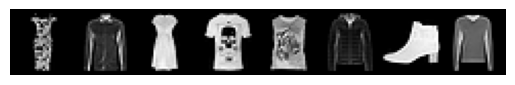

Dress | Shirt | Dress | T-shirt/top | T-shirt/top | Coat | Ankle Boot | Pullover


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision

classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot')

dataiter = iter(train_loader)
images, labels = next(dataiter)

def imshow(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)), cmap='gray')
    plt.axis('off')
    plt.show()

print("Here is a sample of what the network actually sees:")
imshow(torchvision.utils.make_grid(images[:8]))
print(' | '.join(f'{classes[labels[j]]}' for j in range(8)))

In [5]:
class LogisticRegressionBaseline(nn.Module):
    """
    A simple Logistic Regression baseline model using PyTorch.
    Maps flattened 28x28 images (784 pixels) directly to 10 class output scores.
    """
    def __init__(self, input_size=784, num_classes=10):
        super(LogisticRegressionBaseline, self).__init__()
        self.linear = nn.Linear(input_size, num_classes)

    def forward(self, x):
        """
        Defines the forward pass of the model.

        Args:
            x (torch.Tensor): The input batch of images.
        """
# Flatten the image tensors from (batch_size, 1, 28, 28) to (batch_size, 784)
        x = x.view(-1, 28 * 28)
# Pass the flattened tensor through the linear layer
        out = self.linear(x)
        return out

baseline_model = LogisticRegressionBaseline()
print("Baseline Model Architecture:")
print(baseline_model)

Baseline Model Architecture:
LogisticRegressionBaseline(
  (linear): Linear(in_features=784, out_features=10, bias=True)
)


In [6]:
class FlexibleMLP(nn.Module):
    """
    A Deep Feedforward Network with customizable activation functions.
    This allows for systematic ablation studies on convergence rates.
    """
    def __init__(self, activation_fn, input_size=784, hidden1=256, hidden2=128, num_classes=10):
        super(FlexibleMLP, self).__init__()
        # Define the hidden layers
        self.fc1 = nn.Linear(input_size, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        # Define the output layer
        self.fc3 = nn.Linear(hidden2, num_classes)

        # Store the activation function passed in during initialization
        self.activation = activation_fn

    def forward(self, x):
        """
        Defines the forward pass using the chosen activation function.
        """
        x = x.view(-1, 28 * 28)

        #Hidden Layer 1 + Activation
        x = self.activation(self.fc1(x))

        #Hidden Layer 2 + Activation
        x = self.activation(self.fc2(x))

        # Output layer
        out = self.fc3(x)
        return out

In [7]:
def train_and_validate(model, train_loader, val_loader, epochs=5, lr=0.01):
    """
    Trains the model using SGD and evaluates it on the validation set.

    Args:
        model (nn.Module): The PyTorch model to train.
        train_loader (DataLoader): The training data.
        val_loader (DataLoader): The validation data.
        epochs (int): Number of times to loop over the entire dataset.
        lr (float): Learning rate for the optimizer.

    Returns:
        train_losses (list), val_accuracies (list): Metrics for plotting.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    train_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # --- VALIDATION PHASE ---
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        val_acc = 100 * correct / total
        val_accuracies.append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_train_loss:.4f} | Validation Accuracy: {val_acc:.2f}%")

    return train_losses, val_accuracies

In [8]:
# 1. Initialize the four models
print("--- Initializing Models ---")
baseline = LogisticRegressionBaseline()
mlp_relu = FlexibleMLP(nn.ReLU())
mlp_sigmoid = FlexibleMLP(nn.Sigmoid())
mlp_tanh = FlexibleMLP(nn.Tanh())

# 2. Define training hyperparameters
EPOCHS = 5
LEARNING_RATE = 0.05

# 3. Train Baseline
print("\n--- Training Logistic Regression Baseline ---")
base_train_loss, base_val_acc = train_and_validate(baseline, train_loader, test_loader, epochs=EPOCHS, lr=LEARNING_RATE)

# 4. Train ReLU MLP
print("\n--- Training MLP (ReLU) ---")
relu_train_loss, relu_val_acc = train_and_validate(mlp_relu, train_loader, test_loader, epochs=EPOCHS, lr=LEARNING_RATE)

# 5. Train Sigmoid MLP
print("\n--- Training MLP (Sigmoid) ---")
sig_train_loss, sig_val_acc = train_and_validate(mlp_sigmoid, train_loader, test_loader, epochs=EPOCHS, lr=LEARNING_RATE)

# 6. Train Tanh MLP
print("\n--- Training MLP (Tanh) ---")
tanh_train_loss, tanh_val_acc = train_and_validate(mlp_tanh, train_loader, test_loader, epochs=EPOCHS, lr=LEARNING_RATE)

--- Initializing Models ---

--- Training Logistic Regression Baseline ---
Epoch [1/5] - Loss: 0.6825 | Validation Accuracy: 80.60%
Epoch [2/5] - Loss: 0.5175 | Validation Accuracy: 81.07%
Epoch [3/5] - Loss: 0.4838 | Validation Accuracy: 82.68%
Epoch [4/5] - Loss: 0.4651 | Validation Accuracy: 82.76%
Epoch [5/5] - Loss: 0.4533 | Validation Accuracy: 83.22%

--- Training MLP (ReLU) ---
Epoch [1/5] - Loss: 0.7901 | Validation Accuracy: 77.04%
Epoch [2/5] - Loss: 0.4829 | Validation Accuracy: 83.26%
Epoch [3/5] - Loss: 0.4248 | Validation Accuracy: 83.60%
Epoch [4/5] - Loss: 0.3931 | Validation Accuracy: 84.88%
Epoch [5/5] - Loss: 0.3680 | Validation Accuracy: 85.27%

--- Training MLP (Sigmoid) ---
Epoch [1/5] - Loss: 2.0819 | Validation Accuracy: 46.68%
Epoch [2/5] - Loss: 1.1556 | Validation Accuracy: 64.11%
Epoch [3/5] - Loss: 0.8792 | Validation Accuracy: 68.61%
Epoch [4/5] - Loss: 0.7373 | Validation Accuracy: 73.32%
Epoch [5/5] - Loss: 0.6522 | Validation Accuracy: 76.17%

--- Trai

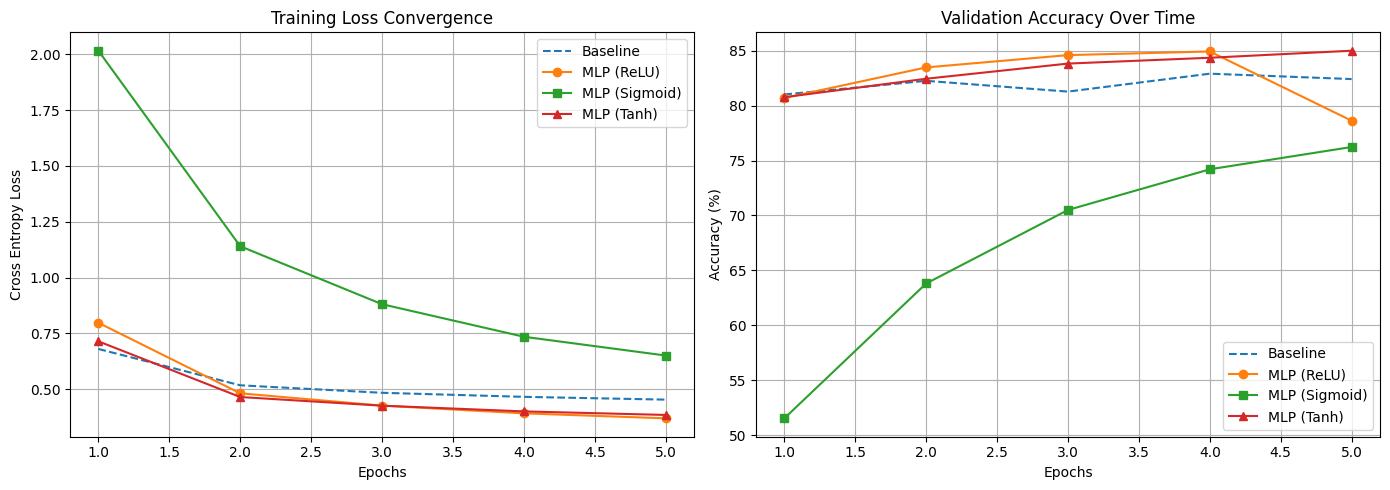

In [ ]:
import matplotlib.pyplot as plt

def plot_experiment_results():
    """
    Plots the training loss and validation accuracy for all evaluated models.
    Generates a side-by-side comparison figure.
    """
    epochs_range = range(1, EPOCHS + 1)
    plt.figure(figsize=(14, 5))

    # --- Plot 1: Training Loss ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, base_train_loss, label='Baseline', linestyle='--')
    plt.plot(epochs_range, relu_train_loss, label='MLP (ReLU)', marker='o')
    plt.plot(epochs_range, sig_train_loss, label='MLP (Sigmoid)', marker='s')
    plt.plot(epochs_range, tanh_train_loss, label='MLP (Tanh)', marker='^')

    plt.title('Training Loss Convergence')
    plt.xlabel('Epochs')
    plt.ylabel('Cross Entropy Loss')
    plt.legend()
    plt.grid(True)

    # --- Plot 2: Validation Accuracy ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, base_val_acc, label='Baseline', linestyle='--')
    plt.plot(epochs_range, relu_val_acc, label='MLP (ReLU)', marker='o')
    plt.plot(epochs_range, sig_val_acc, label='MLP (Sigmoid)', marker='s')
    plt.plot(epochs_range, tanh_val_acc, label='MLP (Tanh)', marker='^')

    plt.title('Validation Accuracy Over Time')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
plot_experiment_results()